In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('../Data/app_train_preprocessed.csv')

In [4]:
from src import run_experiment
from sklearn.linear_model import LogisticRegression

In [5]:
# Солвер 'saga' с penalty='elasticnet' очень долго сходится, поэтому сделаем пока чистую L2-регуляризацию
def log_reg_param_space(trial):
    return {
        "C": trial.suggest_float('C', 1e-3, 1e2, log=True),
        # "l1_ratio": trial.suggest_float('l1_ratio', 0, 1, step=0.1),
        # "penalty": trial.suggest_categorical('penalty', ['elasticnet']),
        # "solver": trial.suggest_categorical('solver', ['saga']),
        "max_iter": trial.suggest_int('max_iter', 100, 1000, step=100)
    }

[I 2026-04-29 23:13:00,317] Using an existing study with name 'LogisticRegression' instead of creating a new one.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:    2.9s finished
[I 2026-04-29 23:13:03,365] Trial 47 finished with value: 0.7427091462940765 and parameters: {'C': 0.13675792948551113, 'max_iter': 200}. Best is trial 46 with value: 0.7427092803310137.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    2.1s remaining:    3.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.2s finished


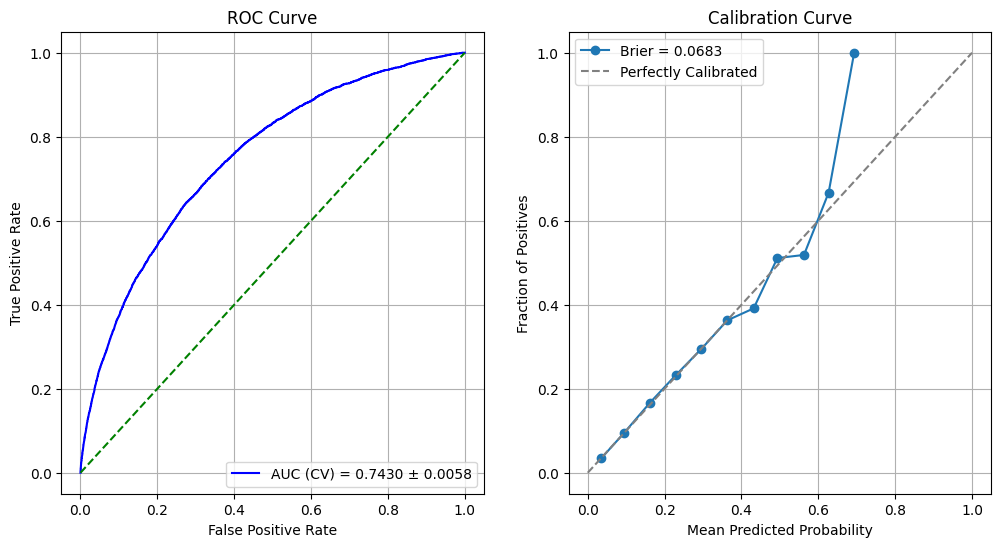

{'auc_mean_cv': np.float64(0.743),
 'auc_std_cv': np.float64(0.0058),
 'brier_score': np.float64(0.0683)}

In [6]:
exp_name = f'check'

run_experiment(
    exp_name,
    LogisticRegression,
    log_reg_param_space,
    df,
    n_trials=1,
    cv_num=2
)